In [1]:
import torch; torch.set_default_tensor_type(torch.cuda.FloatTensor); import torch.nn as nn; import torch.optim as optim
from gprMax.utilities import detect_check_gpus; from gprMax.gprMax import api; import numpy as np; import h5py; import matplotlib.pyplot as plt; import math
import os; import time; from IPython.display import clear_output; os.getcwd(); import torch; from GPUtil import showUtilization as gpu_usage
from numba import cuda; import gc; import pycuda.driver; import random; import time; import pandas as pd; from scipy.signal import hilbert; import csv
from matplotlib.animation import FuncAnimation; from torch.optim.lr_scheduler import StepLR; from scipy.stats import linregress
plt.rcParams['figure.figsize'] = (10, 2); from bayes_opt import BayesianOptimization; from scipy import stats; import seaborn as sns
def norm(signal):
    signal = np.abs(hilbert(signal))    
    signal = signal/np.max(signal)
    return signal
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\wangz\anaconda3\envs\gprMax\Lib\site-packages\torch\__init__.py:1275: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\tensor\python_tensor.cpp:436.)
  _C._set_default_tensor_type(t)


# Data Generation

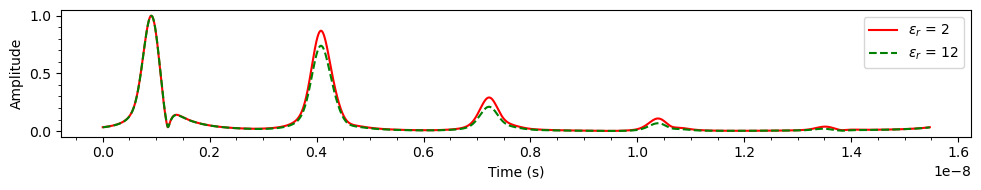

In [2]:
tw= 15.47e-9;    
def model_miniXT_2D(p1,c1, dep, p2=1.356,c2=0.0012, waveform="gaussian", freq=1.44e9, bs=0.062, dd=0.02):
    b=0.02
    X=0.4; Y=0.5; dx=0.001; Z=dx; gpr_Y = dep+b+dd; freq = freq; Tx=X/2-0.04
    with open("Noise.in", "w") as f:
        f.write(f"#title: Soil_15cm + PEC \n#domain: {X} {Y} {Z}\n#dx_dy_dz: {dx} {dx} {dx}")
        f.write(f"\n#time_window: {tw} \n#material: {p1} {c1} 1 0 mat1 \n#material: {p2} {c2} 1 0 mat2")
        f.write(f"\n#waveform: {waveform} 1 {freq} my_wave")
        f.write(f"\n#hertzian_dipole: z {Tx} {gpr_Y} 0 my_wave\n#rx: {Tx+bs} {gpr_Y} 0")
        f.write(f"\n#box: 0 {b} 0 {X} {dep+b} {Z} mat1")        
        f.write(f"\n#box: 0 {dep+b} 0 {X} {dep+b+2*dd} {Z} mat2")        
        f.write(f"\n#box: 0 {b-.01} 0 {X} {b} {Z} pec")
        f.write(f"\n#geometry_view: 0 0 0 {X} {Y} {Z} {dx} {dx} {dx} Soil n\n")
        f.close()

    api("Noise.in", geometry_only=False, gpu=[0])
    hf2 = h5py.File("Noise.out", 'r', libver='latest', swmr=True)
    Ascan = hf2['rxs/rx1/Ez'][:]
    hf2.close()
    clear_output()
    return Ascan

# PERMITTIVITY variation
sim1 = norm(model_miniXT_2D(p1=10, c1=0.001, dep=0.15));
sim2 = norm(model_miniXT_2D(p1=10, c1=0.01, dep=0.15));

t = np.linspace(0, tw, sim1.shape[0]);  

plt.plot(t,sim1, label=r'$\epsilon_r$ = 2', linestyle='-', color='r')
plt.plot(t,sim2, label=r'$\epsilon_r$ = 12', linestyle='--', color='g')

plt.xlabel('Time (s)'); plt.minorticks_on()
plt.ylabel('Amplitude')
plt.legend(loc='best'); 
plt.tight_layout(); plt.show(); 

In [ ]:
p1_values = np.round(np.arange(3, 13, 0.1),1)
c1_values = np.round(np.arange(0, 0.055, 0.001),3)
dep_values = np.round(np.arange(0.15, 0.3, 0.05),2)

p1_values, c1_values, dep_values, len(p1_values)*len(c1_values)*len(dep_values)

(array([ 3. ,  3.1,  3.2,  3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,
         4.1,  4.2,  4.3,  4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,
         5.2,  5.3,  5.4,  5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,
         6.3,  6.4,  6.5,  6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,
         7.4,  7.5,  7.6,  7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,
         8.5,  8.6,  8.7,  8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,
         9.6,  9.7,  9.8,  9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6,
        10.7, 10.8, 10.9, 11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7,
        11.8, 11.9, 12. , 12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8,
        12.9]),
 array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
        0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017,
        0.018, 0.019, 0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026,
        0.027, 0.028, 0.029, 0.03 , 0.031, 0.032, 0.033, 0.034, 0.035,
        0.036, 0.037, 0.038, 0.039

In [ ]:
# Generate simulation data 
# Prepare the data with normalized simulation signals
data = []
for p1 in p1_values:
    for c1 in c1_values:
        for dep in dep_values:
            sim_signal = norm(model_miniXT_2D(p1=p1, c1=c1, dep=dep))
            data.append([p1, c1, dep] + list(sim_signal))

# Save the data to a CSV file
csv_filename = '1_layer_SimData_1547.csv'
with open(csv_filename, 'w', newline='') as file:
    writer = csv.writer(file)
    # Write the header
    writer.writerow(['p1', 'c1', 'depth'] + [f'sim_{i}' for i in range(len(sim_signal))])
    # Write the data rows
    writer.writerows(data)

pd.read_csv(csv_filename)

,p1,c1,depth,sim_0,sim_1,sim_2,sim_3,sim_4,sim_5,sim_6,...,sim_6550,sim_6551,sim_6552,sim_6553,sim_6554,sim_6555,sim_6556,sim_6557,sim_6558,sim_6559
0,3.0,0.000,0.15,0.028349,0.028472,0.028601,0.028729,0.028859,0.028989,0.029122,...,0.027112,0.027231,0.027351,0.027473,0.027594,0.027718,0.027841,0.027966,0.028092,0.028222
1,3.0,0.000,0.20,0.029658,0.029765,0.029897,0.030022,0.030156,0.030286,0.030421,...,0.028351,0.028476,0.028599,0.028727,0.028852,0.028982,0.029109,0.029245,0.029374,0.029528
2,3.0,0.000,0.25,0.030615,0.030674,0.030809,0.030919,0.031055,0.031176,0.031314,...,0.029207,0.029336,0.029459,0.029593,0.029718,0.029859,0.029987,0.030141,0.030271,0.030480
3,3.0,0.001,0.15,0.028281,0.028404,0.028533,0.028661,0.028791,0.028921,0.029053,...,0.027048,0.027167,0.027286,0.027407,0.027529,0.027652,0.027775,0.027900,0.028025,0.028154
4,3.0,0.001,0.20,0.029559,0.029672,0.029804,0.029930,0.030064,0.030194,0.030329,...,0.028269,0.028393,0.028515,0.028642,0.028766,0.028895,0.029021,0.029154,0.029282,0.029429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16495,12.9,0.053,0.20,0.029564,0.030564,0.030667,0.031071,0.031178,0.031466,0.031575,...,0.030330,0.030306,0.030384,0.030336,0.030418,0.030323,0.030409,0.030201,0.030293,0.029495
16496,12.9,0.053,0.25,0.030648,0.030790,0.030919,0.031054,0.031186,0.031321,0.031454,...,0.029432,0.029550,0.029672,0.029791,0.029914,0.030035,0.030159,0.030280,0.030407,0.030521
16497,12.9,0.054,0.15,0.030053,0.029877,0.030016,0.030051,0.030191,0.030270,0.030412,...,0.028116,0.028290,0.028429,0.028613,0.028752,0.028954,0.029092,0.029335,0.029473,0.029922
16498,12.9,0.054,0.20,0.029604,0.030542,0.030647,0.031032,0.031140,0.031416,0.031527,...,0.030232,0.030218,0.030298,0.030261,0.030345,0.030265,0.030354,0.030168,0.030263,0.029530
